# Importing Library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools for preprocessing, splitting, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style='whitegrid')
print("Library imported Successfully")

Library imported Successfully


# Step-1 Loading the Data Set IN Juypter NoteBook

In [28]:
try:
    df = pd.read_csv('data/housing.csv')
    print(f"Data Loaded Successfully {df.shape}")
    print(df.head(7))
except FileNotFoundError:
    print("File Not found")


Data Loaded Successfully (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431      

# step-2 Indentifing Datatype and total count of not-null value 

In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


# Step-3 For data cleaning

In [42]:
df.dropna(inplace=True) # use for cleaning the datasets.. so here it will removed 207 rows
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


# step-4 Train data

In [46]:
x = df.drop(['median_house_value'], axis=1)
y = df['median_house_value']
#-----------------
x_train, x_test, y_train, y_test =  train_test_split(x,y, test_size=0.2)

# just exploring using matpolib and seaborn

In [70]:
train_data=x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
10114,-117.94,33.94,26.0,1962.0,540.0,1236.0,520.0,2.2156,<1H OCEAN,145000.0
1677,-122.25,38.05,30.0,1255.0,297.0,779.0,307.0,1.6767,NEAR BAY,147700.0
1008,-121.76,37.68,35.0,1864.0,357.0,1189.0,349.0,4.2361,INLAND,177500.0
14181,-117.05,32.72,35.0,1777.0,369.0,1158.0,353.0,3.4107,NEAR OCEAN,117000.0
13522,-117.41,34.23,17.0,889.0,131.0,439.0,141.0,6.1426,INLAND,155000.0
...,...,...,...,...,...,...,...,...,...,...
16679,-120.64,35.15,7.0,7922.0,1442.0,2863.0,1197.0,4.8490,<1H OCEAN,275000.0
7077,-117.99,33.94,34.0,1519.0,301.0,758.0,304.0,4.3125,<1H OCEAN,214000.0
17617,-121.94,37.28,18.0,4356.0,1334.0,1968.0,1245.0,3.6294,<1H OCEAN,240000.0
11438,-117.96,33.65,18.0,3603.0,879.0,1549.0,756.0,4.0229,<1H OCEAN,363100.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

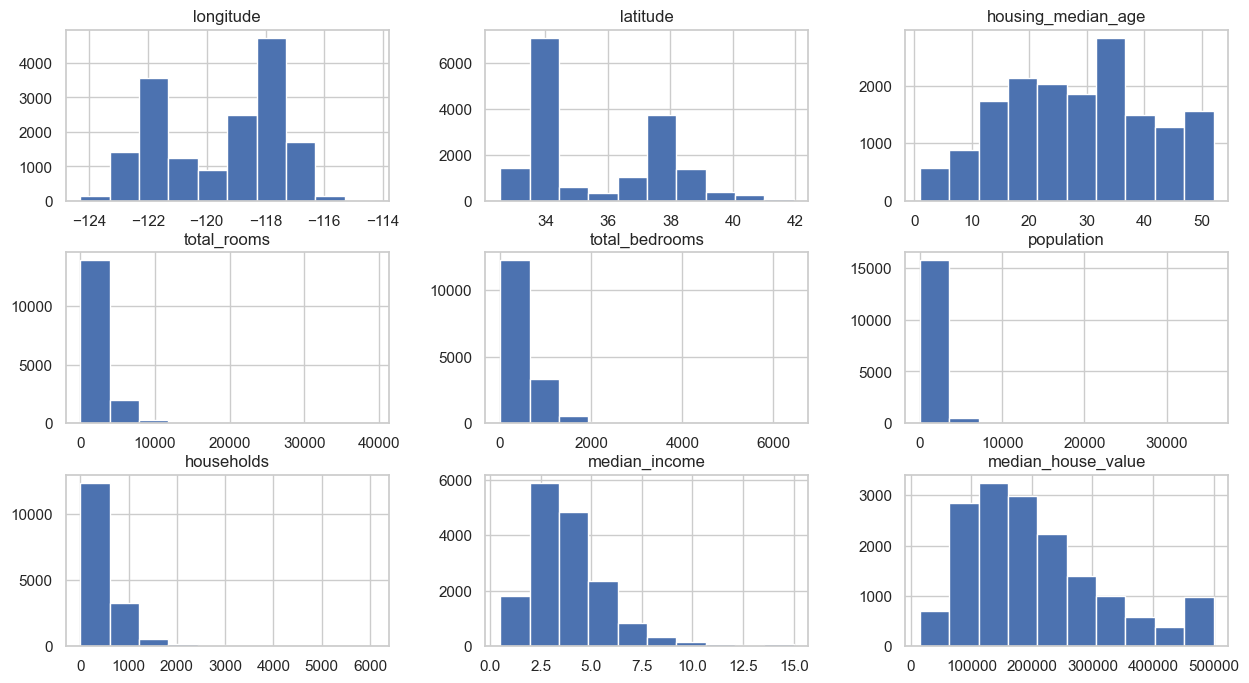

In [53]:
train_data.hist(figsize=(15,8))

<Axes: >

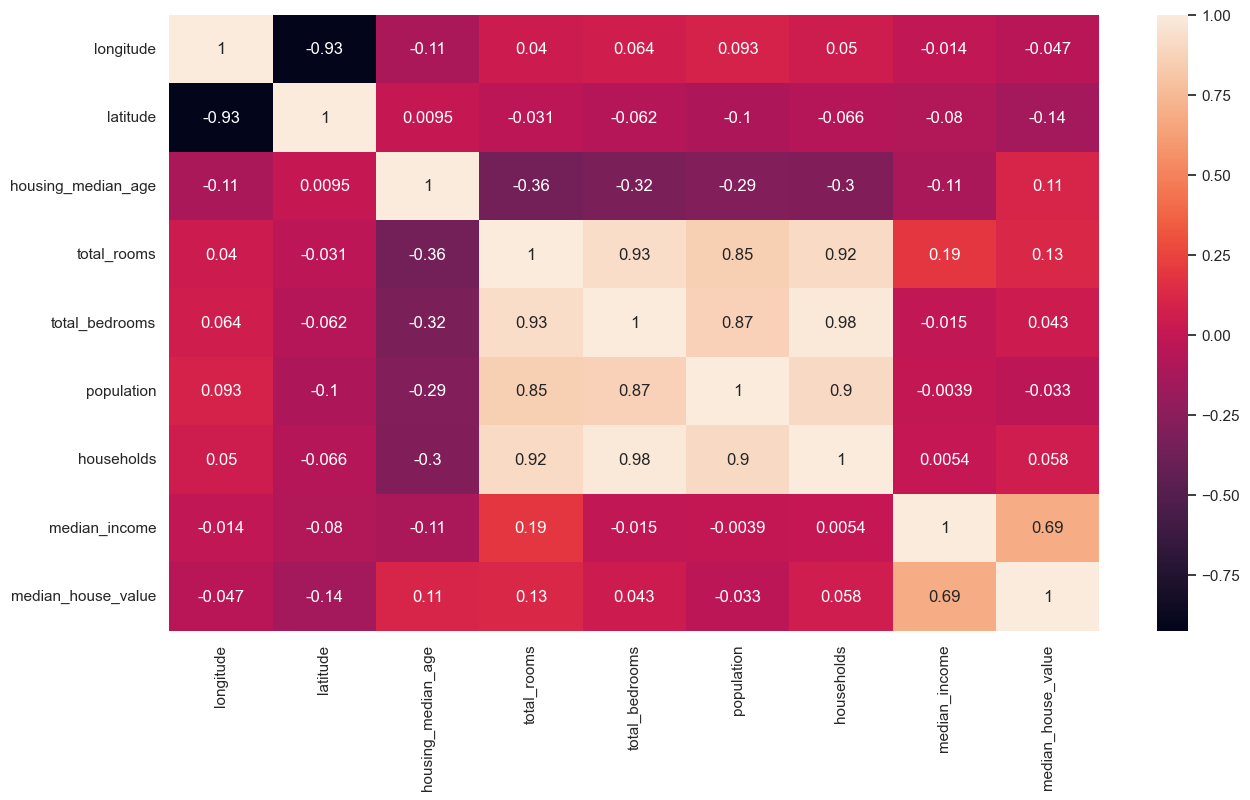

In [62]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

## Here in datasets there ocean procimity which is in string(object) and its an important aspcet for finding houses .. so make this column in use we changes it into binary number

<Axes: >

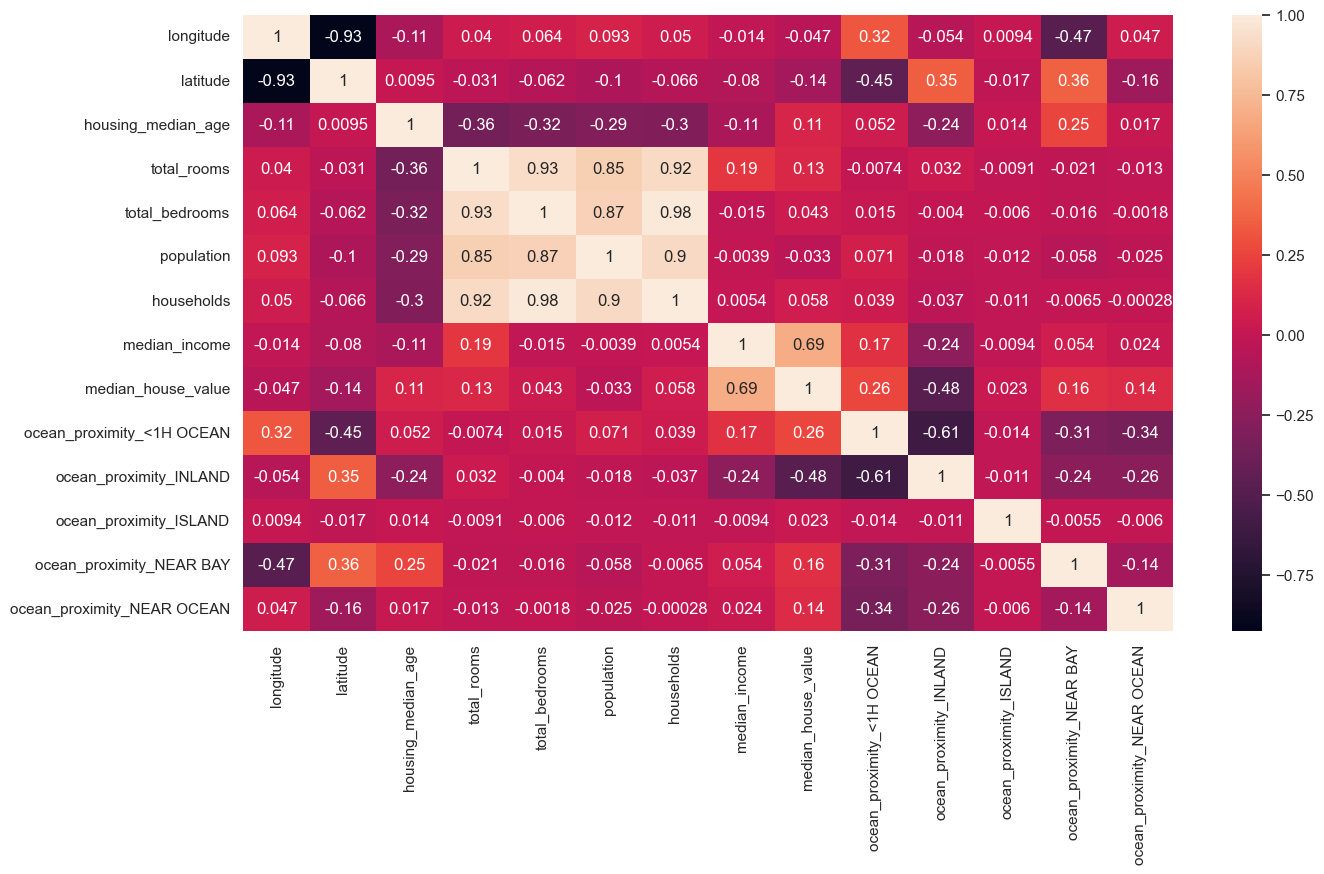

In [ ]:

plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')